# Data Capture

In [96]:
import os
import time
import pandas as pd
from dataretrieval import waterdata
import dataretrieval
import numpy as np
import geopandas as gpd
import shapely as sp

In [76]:
site = waterdata.get_monitoring_locations(monitoring_location_id = "USGS-08068500")[0]
site['geometry'] = site['geometry'].apply(lambda x: sp.Point(x))


Retrieving: monitoring-locations · 1 page · 1 rows · 990/1,000 requests remaining


In [93]:
sites = waterdata.get_monitoring_locations(state_name = "Texas", 
                                          site_type = "Stream")[0].dropna(subset=['geometry'])

Retrieving: monitoring-locations · 1 page · 3,079 rows · 986/1,000 requests remaining


<Axes: >

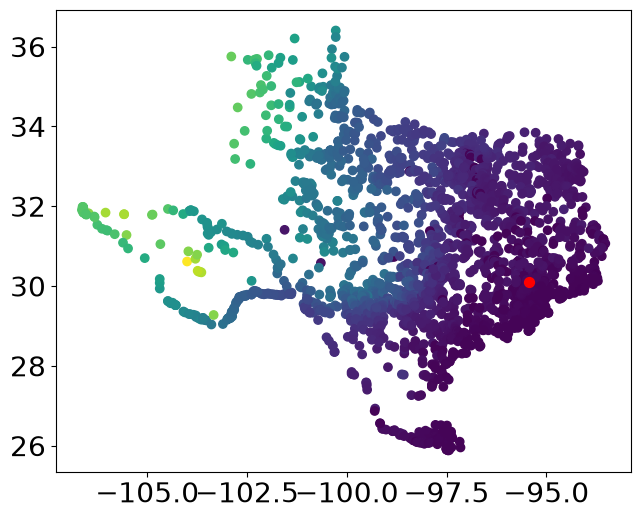

In [95]:
gdf = gpd.GeoDataFrame(sites)
gdf['geometry'] = gdf['geometry'].apply(lambda x: sp.Point(x))
gdf.set_geometry('geometry', inplace=True)

gpd.GeoDataFrame(site).plot(ax=gdf.plot(column='altitude', legend=False, figsize=(10, 6)), color='red', markersize=50)

# Water quality data

In [2]:
parameter_key = [("Instantaneous computed discharge", "00060"),
                 ("Instantaneous water temperature", "00010"),
                 ("Instantaneous pH", "00400"),
                 ("Instantaneous diss. oxygen", "00300"),
                 ("Instantaneous specific conductance at 25 degrees Celsius", "00095"),
                 ("Instantaneous turbidity", "63680"),
                 ]
                #  ("Computed instantaneous total organic carbon", "00680"),
                #  ("Computed instantaneous diss. nitrate + nitrite", "00631"),
                #  ("Computed instantaneous total phosphorus", "00665")]

In [3]:
with open(r"c:\Users\epzausch\Desktop\usgs_waterdata_api_key.txt", "r") as f:
    api_key = f.read().strip()

In [4]:
dataretrieval.configure(dataretrieval.Configuration(api_key=api_key))
import os

os.environ["API_USGS_PAT"] = api_key

In [5]:


def fetch_usgs_data(
    pcode: tuple,
    period: str = "2024",
    refresh: bool = False
) -> pd.DataFrame:

    site_no = "08068500"
    parameter_code = pcode[1]

    fname = f"USGS_{parameter_code}_{period}.csv"
    filepath = os.path.join("USGS", fname)

    # Load cached data
    if not refresh and os.path.exists(filepath):

        print(f"Loading cached data from {fname}...")

        df = pd.read_csv(filepath)

        # Convert to timezone-naive datetime
        df["DateTime"] = (
            pd.to_datetime(df["DateTime"], utc=True)
            .dt.tz_localize(None)
        )

        df.set_index("DateTime", inplace=True)

        return df

    # Fetch data from USGS
    print(
        f"Fetching {parameter_code} data for {period} from USGS..."
    )

    start_date = f"{period}-01-01"
    end_date = f"{int(period) + 1}-01-01"

    df, metadata = waterdata.get_continuous(
        monitoring_location_id=f"USGS-{site_no}",
        parameter_code=parameter_code,
        time=f"{start_date}/{end_date}",
    )

    # Standardize output

    # Convert USGS timezone-aware timestamps to timezone-naive
    df["DateTime"] = (
        pd.to_datetime(df["time"], utc=True)
        .dt.tz_localize(None)
    )

    df.set_index("DateTime", inplace=True)

    # Keep only the measured value
    df = df[["value"]].copy()

    # Rename to your parameter name
    df.rename(columns={"value": pcode[0]}, inplace=True)

    # Remove duplicate timestamps
    df = df[~df.index.duplicated(keep="first")]

    # Sort chronologically
    df.sort_index(inplace=True)

    # Save cache
    os.makedirs("USGS", exist_ok=True)

    df.to_csv(filepath)

    return df


def fetch_many_years(
    pcode: tuple,
    start_year: int,
    end_year: int,
    refresh: bool = False
) -> pd.DataFrame:
    """
    Fetch USGS continuous data for multiple years and concatenate
    into a single DataFrame.
    """

    dfs = []

    for year in range(start_year, end_year + 1):

        df_year = fetch_usgs_data(
            pcode=pcode,
            period=str(year),
            refresh=refresh
        )

        dfs.append(df_year)

        # Pause between requests to avoid hitting the USGS service
        time.sleep(1)

    combined_df = pd.concat(dfs)

    # Remove any duplicate timestamps created at year boundaries
    combined_df = combined_df[
        ~combined_df.index.duplicated(keep="first")
    ]

    combined_df.sort_index(inplace=True)

    return combined_df


def fetch_all_parameters(
    start_year: int,
    end_year: int,
    refresh: bool = False
) -> pd.DataFrame:
    """
    Fetch USGS continuous data for all parameters in parameter_key
    and combine them into a single DataFrame.
    """

    dfs = []

    for pcode in parameter_key:

        print(f"\nFetching data for parameter {pcode[0]}...")

        df_param = fetch_many_years(
            pcode=pcode,
            start_year=start_year,
            end_year=end_year,
            refresh=refresh
        )

        dfs.append(df_param)

    combined_df = pd.concat(
        dfs,
        axis=1,
        join="outer",
        sort=True
    )

    combined_df.sort_index(inplace=True)

    return combined_df

In [6]:
df = fetch_all_parameters(start_year=2009, end_year=2025, refresh=False)


Fetching data for parameter Instantaneous computed discharge...
Loading cached data from USGS_00060_2009.csv...
Loading cached data from USGS_00060_2010.csv...
Loading cached data from USGS_00060_2011.csv...
Loading cached data from USGS_00060_2012.csv...
Loading cached data from USGS_00060_2013.csv...
Loading cached data from USGS_00060_2014.csv...
Loading cached data from USGS_00060_2015.csv...
Loading cached data from USGS_00060_2016.csv...
Loading cached data from USGS_00060_2017.csv...
Loading cached data from USGS_00060_2018.csv...
Loading cached data from USGS_00060_2019.csv...
Loading cached data from USGS_00060_2020.csv...
Loading cached data from USGS_00060_2021.csv...
Loading cached data from USGS_00060_2022.csv...
Loading cached data from USGS_00060_2023.csv...
Loading cached data from USGS_00060_2024.csv...
Loading cached data from USGS_00060_2025.csv...

Fetching data for parameter Instantaneous water temperature...
Loading cached data from USGS_00010_2009.csv...
Loading

In [7]:
df

,Instantaneous computed discharge,Instantaneous water temperature,Instantaneous pH,Instantaneous diss. oxygen,Instantaneous specific conductance at 25 degrees Celsius,Instantaneous turbidity
DateTime,,,,,,
2009-01-01 00:00:00,74.9,NaN,NaN,NaN,NaN,NaN
2009-01-01 00:15:00,74.9,NaN,NaN,NaN,NaN,NaN
2009-01-01 00:30:00,71.7,NaN,NaN,NaN,NaN,NaN
2009-01-01 00:45:00,71.7,NaN,NaN,NaN,NaN,NaN
2009-01-01 01:00:00,71.7,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-12-31 23:00:00,11.1,14.9,8.2,12.3,680.0,7.4
2025-12-31 23:15:00,11.6,14.9,8.2,12.2,680.0,7.6
2025-12-31 23:30:00,12.1,14.9,8.2,12.0,680.0,7.6


In [8]:
df.to_csv("USGS_data.csv")

In [9]:
df.describe()

,Instantaneous computed discharge,Instantaneous water temperature,Instantaneous pH,Instantaneous diss. oxygen,Instantaneous specific conductance at 25 degrees Celsius,Instantaneous turbidity
count,591857.000000,546264.000000,543676.000000,541305.000000,533116.000000,509768.000000
mean,365.163584,22.433346,7.550811,8.215677,425.936018,49.471083
std,1818.556685,6.793330,0.444087,1.902357,180.716216,51.271834
min,3.620000,2.100000,6.000000,0.800000,26.000000,1.100000
25%,38.100000,17.000000,7.300000,6.800000,293.000000,18.000000
50%,71.900000,23.100000,7.500000,8.100000,422.000000,32.600000
75%,190.000000,28.000000,7.700000,9.400000,545.000000,63.500000
max,78400.000000,38.200000,10.800000,19.300000,1140.000000,1440.000000


In [10]:
column_map = {
    "Instantaneous computed discharge": "Discharge (cfs)",
    "Instantaneous water temperature": "Water Temperature (C)",
    "Instantaneous pH": "pH (std units)",
    "Instantaneous diss. oxygen": "Dissolved Oxygen (mg/L)",
    "Instantaneous specific conductance at 25 degrees Celsius": "Specific Conductance (uS/cm)",
    "Instantaneous turbidity": "Turbidity (NTU)",
    "Computed instantaneous total organic carbon": "Total Organic Carbon (mg/L)",
    "Computed instantaneous diss. nitrate + nitrite": "Nitrate + Nitrite (mg/L)",
    "Computed instantaneous total phosphorus": "Total Phosphorus (mg/L)"}
df.rename(columns=column_map, inplace=True)

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

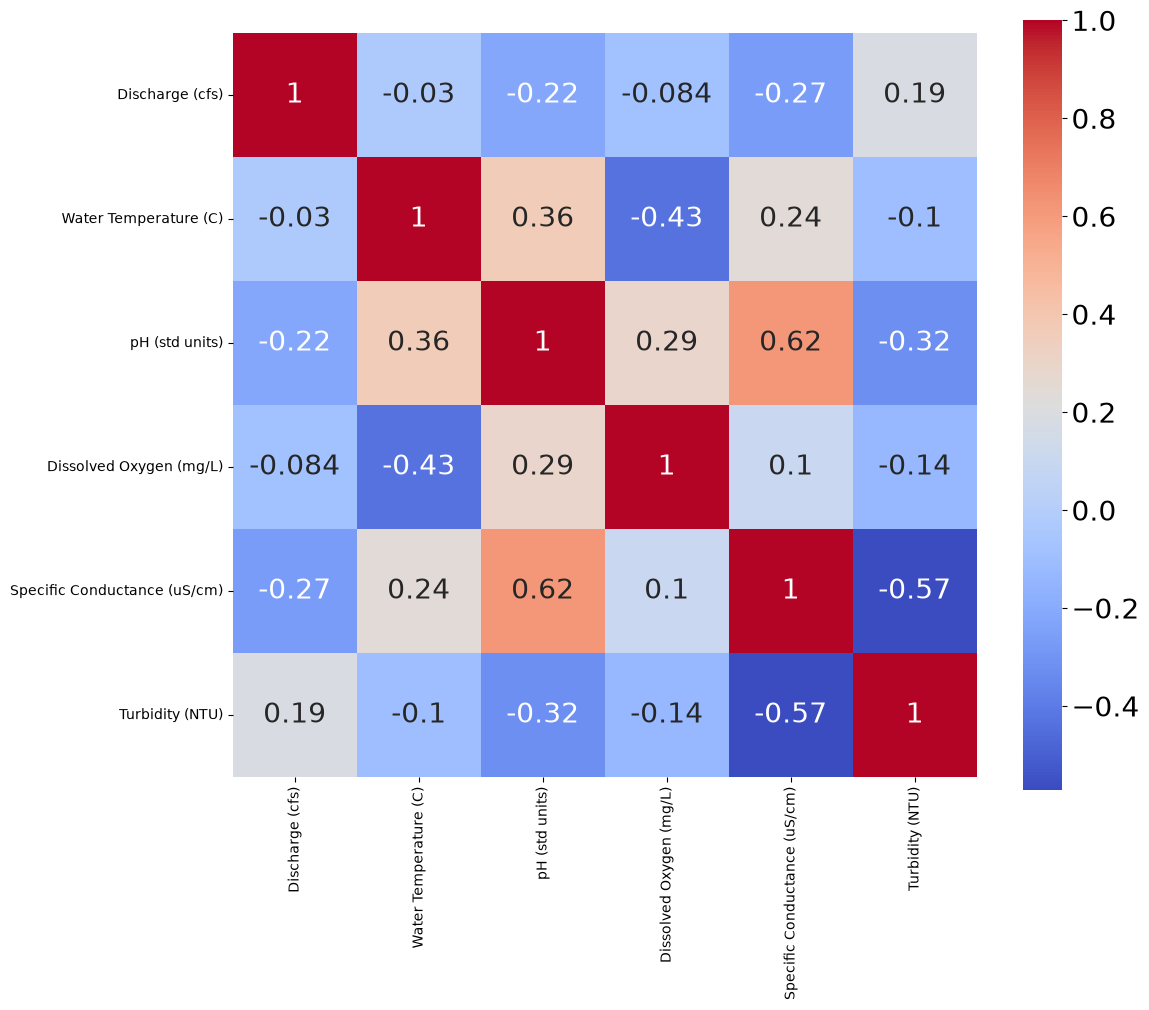

In [12]:
fig, ax = plt.subplots(figsize=(12,10))
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
#num_cols = num_cols.append(merged.columns[-1:])
corr = df[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=True, cmap="coolwarm",ax=ax)
ax.set_aspect(1)

In [13]:
df.index.name = "DateTime"

In [14]:
df.to_csv("USGS_data.csv")